### What's in this notebook
#### Trained a Decision Tree Classifier on iris dataset

### Decision Tree Important Parameters
#### 'criterion': Grading formula to measure split quality. "gini" by default (can also be "entropy").
#### 'splitter': Strategy to choose the split at each node. "best" by default (tests all thresholds, "random" is faster).
#### 'max_depth': Maximum levels/questions deep the tree can go. None by default (grows infinitely until perfectly pure).
#### 'min_samples_split': Minimum rows needed in a group to allow another split. 2 by default.
#### 'min_samples_leaf': Minimum rows required to form a final prediction leaf. 1 by default.
#### 'max_features': Number of columns to look at when deciding a split. None by default (looks at all columns).
#### 'max_leaf_nodes': Maximum total number of final leaves allowed. None by default (infinite leaves).
#### 'max_leaf_nodes': Maximum total number of final leaves allowed. None by default (infinite leaves).
#### 'class_weight': Balances class distribution by assigning weights to rare categories. None by default (all classes treated equally).
#### 'ccp_alpha': Aggressiveness of pruning (chopping off weak branches after growth to prevent overfitting). 0.0 by default (no pruning).

In [1]:
# required libraries

In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np

In [11]:
# loading the dataset
data= load_iris()
X= pd.DataFrame(data.data, columns= data.feature_names)
y= data.target

In [12]:
X

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [13]:
y


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [16]:
# splitting data into train and test
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.3, random_state=42)

In [15]:
X_train

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
81,5.5,2.4,3.7,1.0
133,6.3,2.8,5.1,1.5
137,6.4,3.1,5.5,1.8
75,6.6,3.0,4.4,1.4
109,7.2,3.6,6.1,2.5
...,...,...,...,...
71,6.1,2.8,4.0,1.3
106,4.9,2.5,4.5,1.7
14,5.8,4.0,1.2,0.2
92,5.8,2.6,4.0,1.2


In [18]:
# defining the model
clf= DecisionTreeClassifier(random_state=1)

In [39]:
# training
clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=1)

In [20]:
y_pred= clf.predict(X_test)

In [21]:
y_pred

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 1, 0, 0, 2, 1, 0, 0, 0, 2, 1, 1, 0,
       0])

In [40]:
# checking accuracy
accuracy= accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')

Accuracy: 1.0


In [41]:
# It is clear that with default hyperparameters, our model is overfitting. Let's do hyperparameter tuning.

In [24]:
# Hyperparameter Tuning

In [25]:
from sklearn.model_selection import GridSearchCV

In [42]:
# defining our parameters to experiment with
param_grid= {
    'max_depth': range(1, 10, 1),
    'min_samples_leaf': range(1, 20, 2),
    'min_samples_split': range(2,20,2),
    'criterion': ['entropy', 'gini']
}

In [27]:
tree= DecisionTreeClassifier(random_state=1)

In [30]:
grid_search= GridSearchCV(estimator=tree, param_grid= param_grid, cv= 5, verbose= True)

In [31]:
grid_search.fit(X_train, y_train)
print(f'Best Accuracy: {grid_search.best_score_}')
print(f'Best Parameters: {grid_search.best_estimator_}')

Fitting 5 folds for each of 1620 candidates, totalling 8100 fits
Best Accuracy: 0.9428571428571428
Best Parameters: DecisionTreeClassifier(criterion='entropy', max_depth=4, min_samples_leaf=5,
                       random_state=1)


In [32]:
# visualizing our tree

In [33]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt


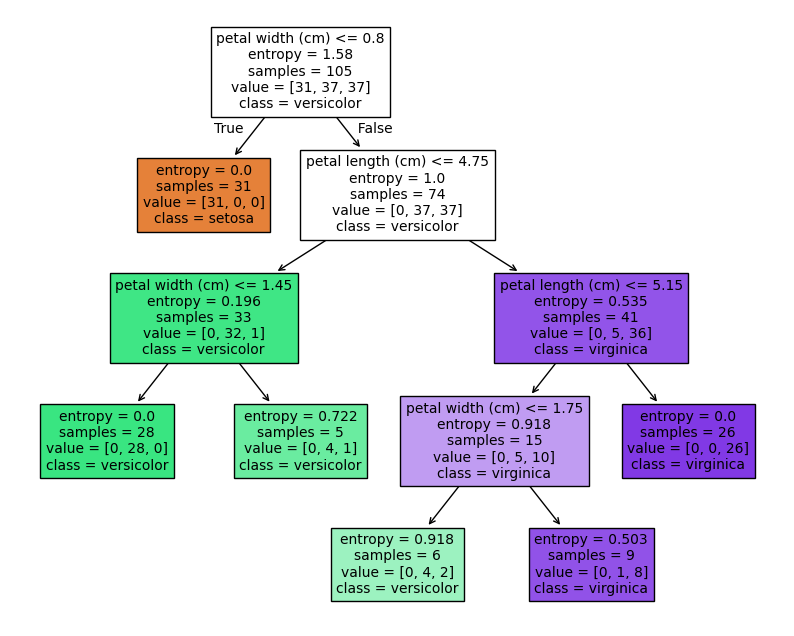

In [38]:
tree_clf= grid_search.best_estimator_
plt.figure(figsize=(10, 8))
plot_tree(tree_clf, filled= True, feature_names= data.feature_names, class_names= data.target_names)
plt.show()